# Project 1: Image Noise Removal Using an Autoencoder on MNIST



## 1. Import Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Prepare MNIST

---

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


## 3. Add Noise to Images



In [3]:
def add_gaussian_noise(images, noise_factor=0.35):
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = images + noise
    return np.clip(noisy_images, 0.0, 1.0)

noise_factor = 0.35
x_train_noisy = add_gaussian_noise(x_train, noise_factor)
x_test_noisy = add_gaussian_noise(x_test, noise_factor)

print("Noisy training data shape:", x_train_noisy.shape)
print("Noisy test data shape:", x_test_noisy.shape)

Noisy training data shape: (60000, 28, 28, 1)
Noisy test data shape: (10000, 28, 28, 1)


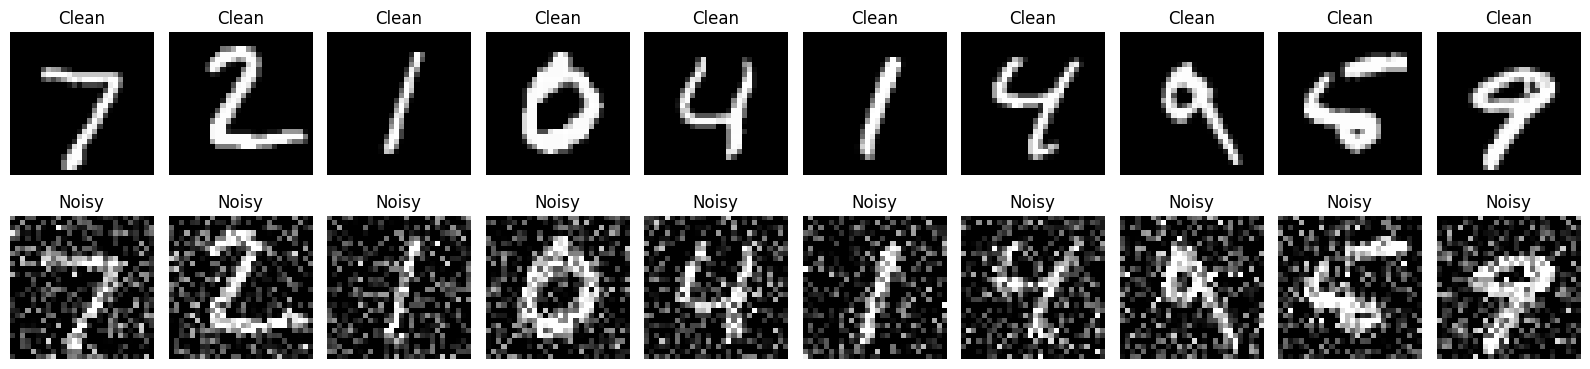

In [4]:
def show_image_grid(clean_images, noisy_images, n=10):
    plt.figure(figsize=(16, 4))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(clean_images[i].squeeze(), cmap="gray")
        plt.title("Clean")
        plt.axis("off")

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(noisy_images[i].squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_image_grid(x_test, x_test_noisy)

## 4. Build the Convolutional Denoising Autoencoder


In [5]:
input_img = layers.Input(shape=(28, 28, 1), name="noisy_image")

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same", name="encoded_representation")(x)

# Decoder
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="denoised_image")(x)

autoencoder = models.Model(input_img, decoded, name="mnist_denoising_autoencoder")
autoencoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

autoencoder.summary()

Model: "mnist_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_representation          │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ denoised_image (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model



In [6]:
EPOCHS = 10
BATCH_SIZE = 128

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 150s 394ms/step - loss: 0.1134 - mae: 0.1358 - val_loss: 0.1111 - val_mae: 0.1298
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 148s 395ms/step - loss: 0.1122 - mae: 0.1309 - val_loss: 0.1111 - val_mae: 0.1298
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 204s 400ms/step - loss: 0.1122 - mae: 0.1309 - val_loss: 0.1111 - val_mae: 0.1298
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 151s 404ms/step - loss: 0.1122 - mae: 0.1309 - val_loss: 0.1111 - val_mae: 0.1298


## 6. Plot Training History

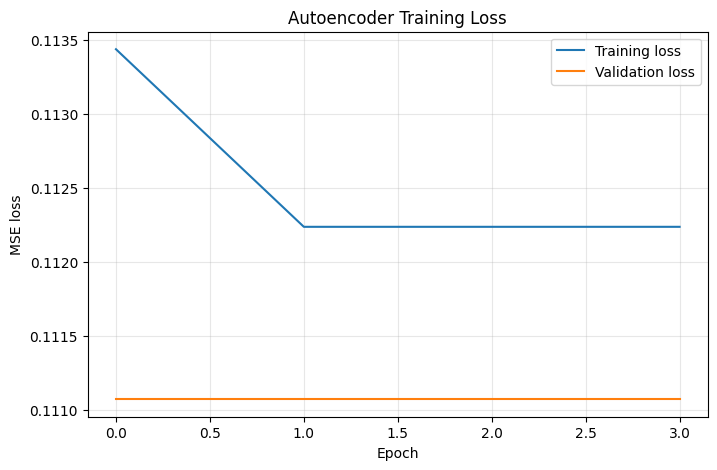

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Evaluate on Test Images

In [8]:
test_loss, test_mae = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"Test MSE: {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

denoised_images = autoencoder.predict(x_test_noisy)

def calculate_psnr(clean, reconstructed):
    mse = np.mean((clean - reconstructed) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(1.0 / np.sqrt(mse))

noisy_psnr = calculate_psnr(x_test, x_test_noisy)
denoised_psnr = calculate_psnr(x_test, denoised_images)

print(f"PSNR before denoising: {noisy_psnr:.2f} dB")
print(f"PSNR after denoising: {denoised_psnr:.2f} dB")

Test MSE: 0.113958
Test MAE: 0.132518
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
PSNR before denoising: 12.05 dB
PSNR after denoising: 9.43 dB


## 8. Visualize Denoising Results

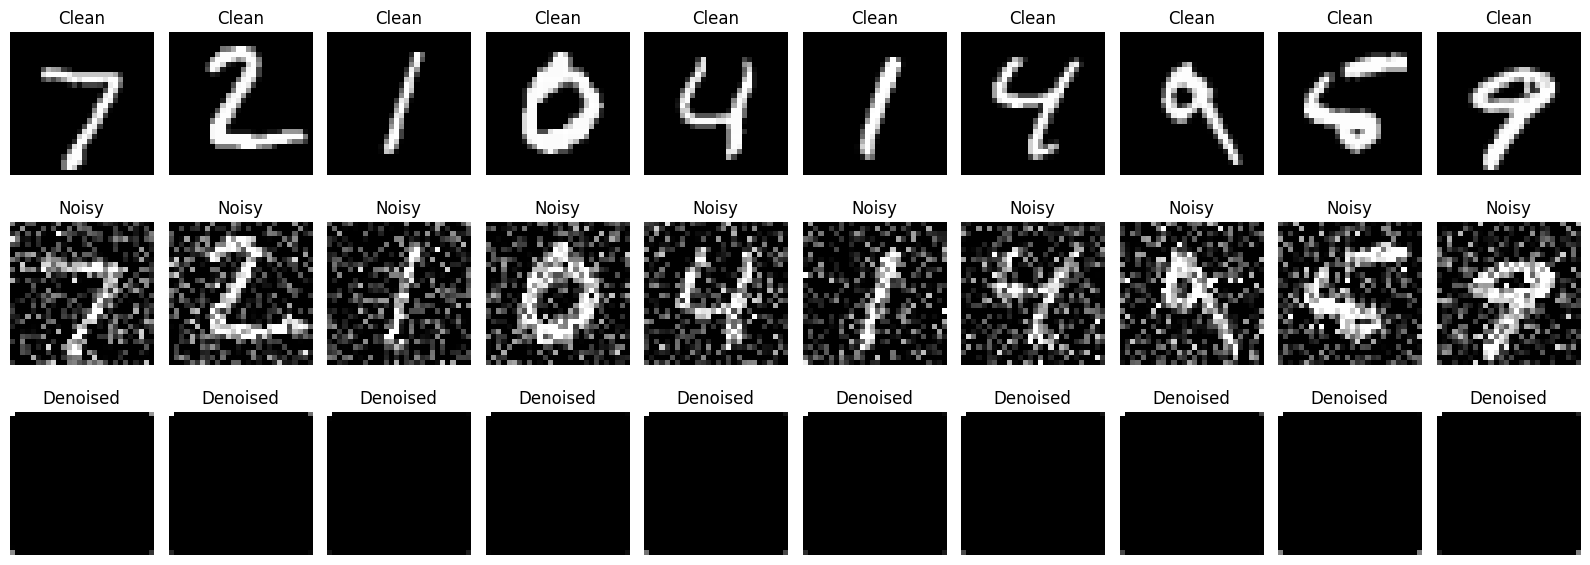

In [9]:
def show_denoising_results(clean_images, noisy_images, denoised_images, n=10):
    plt.figure(figsize=(16, 6))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(clean_images[i].squeeze(), cmap="gray")
        plt.title("Clean")
        plt.axis("off")

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy_images[i].squeeze(), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(denoised_images[i].squeeze(), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_denoising_results(x_test, x_test_noisy, denoised_images)

## 9. Save the Trained Model

The trained model is saved in Keras format so it can be loaded later for inference.

In [10]:
model_path = "mnist_denoising_autoencoder.keras"
autoencoder.save(model_path)
print(f"Model saved to: {os.path.abspath(model_path)}")

Model saved to: /content/mnist_denoising_autoencoder.keras


## 10. Conclusion

The convolutional autoencoder learns compact image features from noisy MNIST digits and reconstructs cleaner images. The denoising quality can be improved further by training for more epochs, tuning the noise factor, adding more convolution layers, or experimenting with deeper encoder-decoder architectures.